In [1]:
# Mounting G-Drive
from google.colab import drive
drive.mount('/content/drive')


# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import os
from PIL import Image
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn
import math
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt





# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [2]:
# Paths for Dataset

data_dir = '/content/drive/My Drive/Lung Disease Dataset'
train_dir = f"{data_dir}/train"
val_dir = f"{data_dir}/val"
test_dir = f"{data_dir}/test"


In [3]:
# 4. Transforms and dataloaders
img_size = 224
batch_size = 32

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

class_names = train_data.classes
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


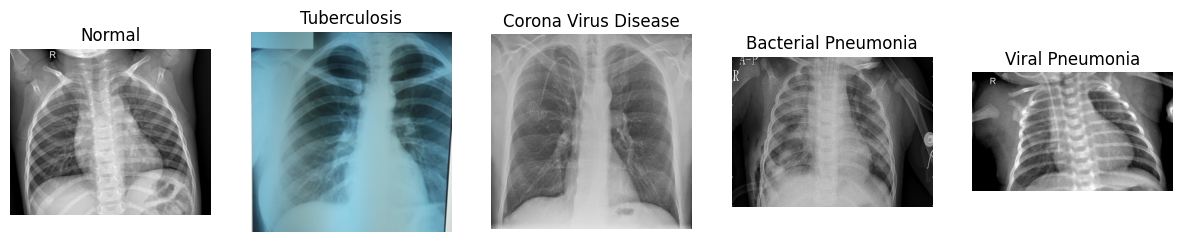

In [4]:
# 5. Visualize a sample image per class (optional, comment out if not needed)

plt.figure(figsize=(15,6))
class_dirs = [os.path.join(train_dir, cls) for cls in os.listdir(train_dir)]
for idx, class_dir in enumerate(class_dirs):
    img_file = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_file)
    img = Image.open(img_path)
    plt.subplot(1, 5, idx+1)
    plt.imshow(img, cmap='gray')
    plt.title(os.path.basename(class_dir))
    plt.axis('off')
plt.show()

In [5]:
# 6. Model: efficientnet_b0


# Load EfficientNet-B0 with pretrained weights
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False  # Freeze backbone for now

# Custom classifier head (2 layers + ReLU + Dropout)

in_features = model.classifier[1].in_features  # EfficientNet's global pool output

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)
model = model.to(device)

In [13]:
# 7. Loss, optimizer, scheduler

# Unfreeze only the last two MBConv blocks of EfficientNet-B0
for p in model.features.parameters():
    p.requires_grad = False

# Identify last two blocks & unfreeze them
last_blocks = list(model.features.children())[-2:]
for blk in last_blocks:
    for p in blk.parameters():
        p.requires_grad = True

# Optimizer with discriminative LRs (backbone lower LR, head higher LR)
head_params = list(model.classifier.parameters())
backbone_params = []
for blk in last_blocks:
    backbone_params += list(blk.parameters())

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": 3e-5, "weight_decay": 1e-4},
    {"params": head_params, "lr": 3e-4, "weight_decay": 1e-4},
])

# Label smoothing helps with mutually-confusable classes(especially for Pneumonia(Viral/Bacterial))
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Cosine with warmup
total_epochs = 15
warmup_epochs = 2
total_steps = total_epochs * len(train_loader)
warmup_steps = warmup_epochs * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


# 8. Training loop

train_losses = []
val_accuracies = []

epochs = 20
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())
best_val_acc = 0.0
patience, patience_ctr = 5, 0

for epoch in range(1, total_epochs + 1):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item() * images.size(0)

    # --- validation ---
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(images)
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch}/{total_epochs} - Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.4f}")

    # early stopping + checkpoint
    if val_acc > best_val_acc + 1e-4:
        best_val_acc = val_acc
        patience_ctr = 0
        torch.save(model.state_dict(), "efficientnet_b0_best.pt")
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print("Early stopping triggered.")
            break

print("Best Val Acc:", best_val_acc)









/tmp/ipython-input-2884477819.py:48: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-2884477819.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipython-input-2884477819.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('c

Epoch 1/15 - Loss: 0.6333 - Val Acc: 0.8304
Epoch 2/15 - Loss: 0.6357 - Val Acc: 0.8338
Epoch 3/15 - Loss: 0.6378 - Val Acc: 0.8388
Epoch 4/15 - Loss: 0.6295 - Val Acc: 0.8423
Epoch 5/15 - Loss: 0.6251 - Val Acc: 0.8522
Epoch 6/15 - Loss: 0.6160 - Val Acc: 0.8482
Epoch 7/15 - Loss: 0.6105 - Val Acc: 0.8636
Epoch 8/15 - Loss: 0.6035 - Val Acc: 0.8487
Epoch 9/15 - Loss: 0.6015 - Val Acc: 0.8378
Epoch 10/15 - Loss: 0.5970 - Val Acc: 0.8442
Epoch 11/15 - Loss: 0.5934 - Val Acc: 0.8353
Epoch 12/15 - Loss: 0.5898 - Val Acc: 0.8452
Early stopping triggered.
Best Val Acc: 0.8635912698412699


Test Accuracy: 0.8809876543209877

Classification Report:
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.82      0.74      0.78       403
Corona Virus Disease       0.95      0.99      0.97       407
              Normal       0.87      0.97      0.92       404
        Tuberculosis       0.99      0.96      0.97       408
     Viral Pneumonia       0.76      0.74      0.75       403

            accuracy                           0.88      2025
           macro avg       0.88      0.88      0.88      2025
        weighted avg       0.88      0.88      0.88      2025



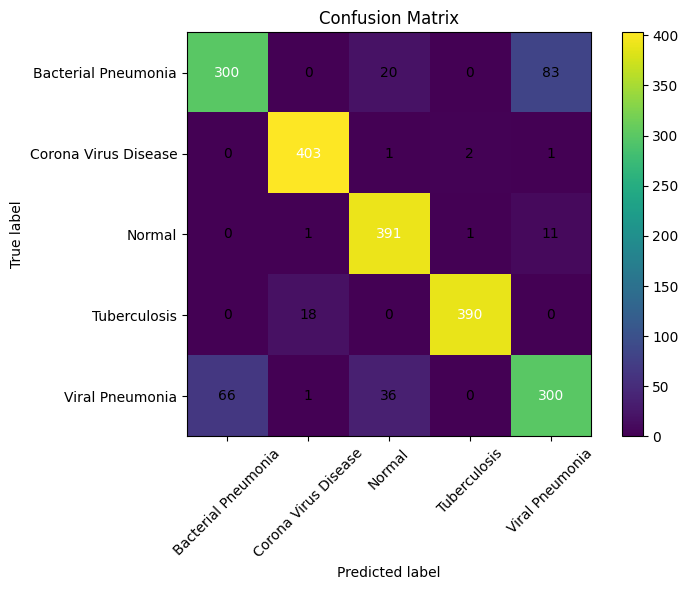

Macro ROC-AUC (OvR): 0.979775831852867


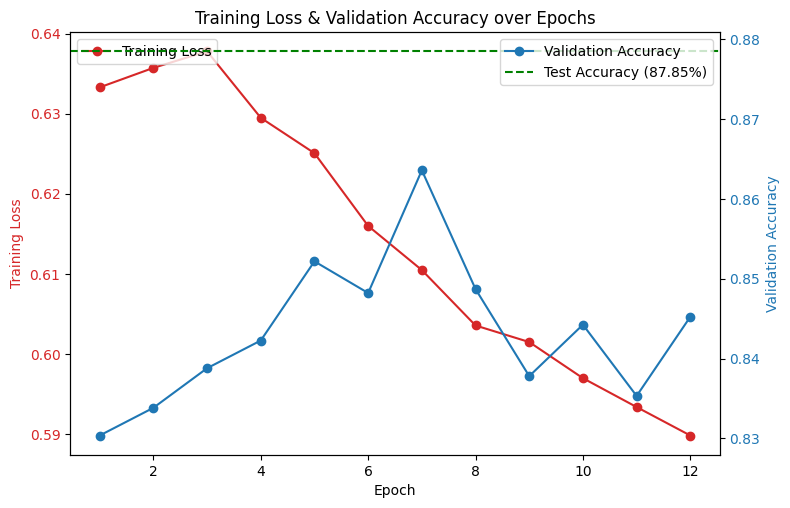

In [17]:


# Load best weights
model.load_state_dict(torch.load("efficientnet_b0_best.pt", map_location=device))
model.eval()

all_labels, all_probs, all_preds = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(1)
        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("Test Accuracy:", (all_preds == all_labels).mean())
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True label'); plt.xlabel('Predicted label'); plt.tight_layout()
plt.show()

# One-vs-rest ROC-AUC (macro)
y_true_ovr = np.eye(len(class_names))[all_labels]
macro_auc = roc_auc_score(y_true_ovr, all_probs, average='macro', multi_class='ovr')
print("Macro ROC-AUC (OvR):", macro_auc)



# PLOTS


epochs_range = range(1, len(train_losses) + 1)

fig, ax1 = plt.subplots(figsize=(8,5))

# Training loss (left y-axis)
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs_range, train_losses, color=color, marker='o', label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)

# Validation accuracy (right y-axis)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Validation Accuracy', color=color)
ax2.plot(epochs_range, val_accuracies, color=color, marker='o', label='Validation Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

# Add horizontal line for Test Accuracy
test_acc_value = (all_preds == all_labels).mean()
ax2.axhline(y=test_acc_value, color='green', linestyle='--', linewidth=1.5, label=f'Test Accuracy ({test_acc_value:.2%})')

# Legends
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Training Loss & Validation Accuracy over Epochs')
plt.show()


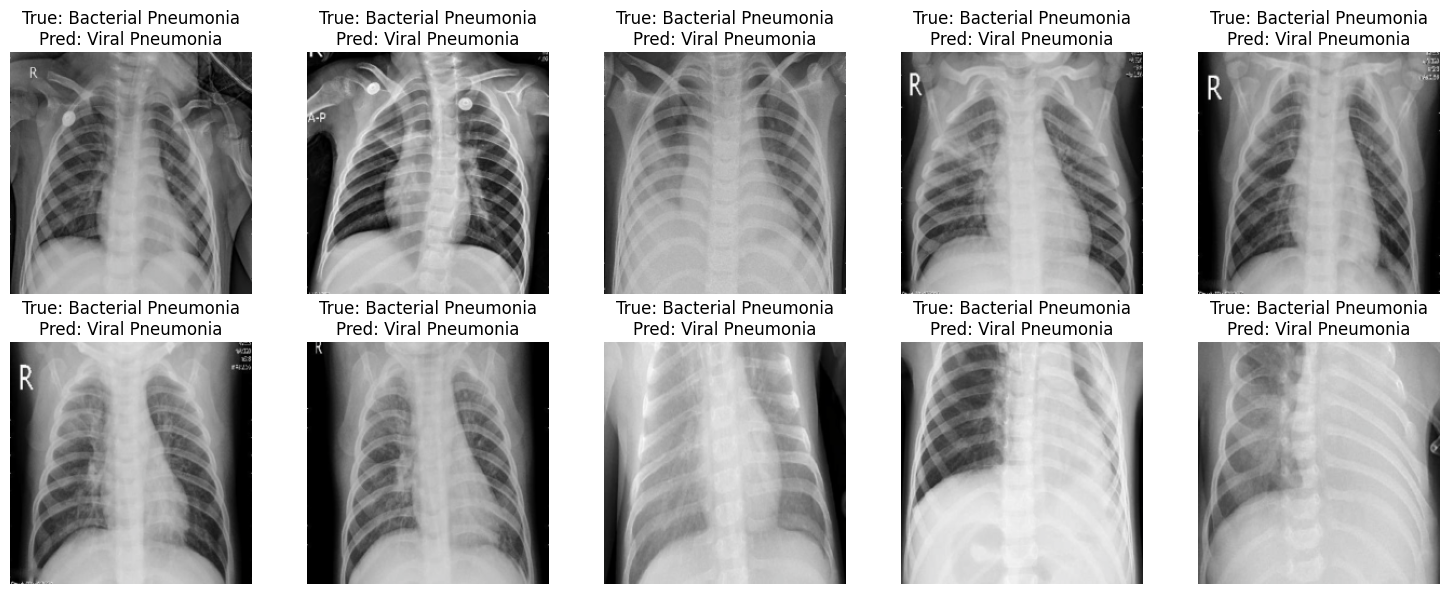

In [22]:


def show_misclassified(test_loader, model, class_names, device, n=10):
    model.eval()
    misclassified = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                if len(misclassified) >= n:
                    break
            if len(misclassified) >= n:
                break
    plt.figure(figsize=(15, 6))
    for i, (img, true, pred) in enumerate(misclassified):
        img = img.numpy().transpose((1,2,0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.subplot(2, n//2, i+1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Usage:
show_misclassified(test_loader, model, class_names, device, n=10)
